In [1]:
from pathlib import Path
import os


class results_obj:
    topology: str
    data_rate: float
    mcs_type: int
    folder_location: str
    short_location: str
    
    
    def __init__(self, topology, data_rate, mcs_type, folder_location, short_location):
        self.topology = topology
        self.data_rate = data_rate
        self.mcs_type = mcs_type
        self.folder_location = folder_location
        self.short_location = short_location

    def __repr__(self):
        return f'Topology: {self.topology}, data_rate: {self.data_rate}, mcs_type: {self.mcs_type}, Folder: {self.folder_location}'
        

def aggregate_data(results_path: str) -> list:
    results_folder = Path(results_path).resolve()
    folders = [f.name for f in results_folder.iterdir() if f.is_dir()]
    results_objs = []
    for folder in folders:
        parts = folder.split("_")
        topology = f'{parts[0]}_{parts[1]}_{parts[2]}'
        data_rate = float(f'{parts[4].split("-")[0]}.{parts[4].split("-")[1]}')
        mcs_type = int(parts[5])
        obj = results_obj(topology,data_rate,mcs_type,f'{os.path.join(results_path,folder)}',folder)
        results_objs.append(obj)
    return results_objs

# results_folder = Path('Results_Multi_N100/').resolve()
# results = aggregate_data(results_folder)
# print(results)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import PatchCollection
import re

Delay-over-time plot saved to: C:\Users\Ameliyn\MCA_Routing_BSCAP\Results_Multi_N100\delay_over_time_1-5Mbps.png
Delay-over-time plot saved to: C:\Users\Ameliyn\MCA_Routing_BSCAP\Results_Multi_N100\delay_over_time_2-0Mbps.png
Delay-over-time plot saved to: C:\Users\Ameliyn\MCA_Routing_BSCAP\Results_Multi_N100\delay_over_time_4-0Mbps.png
Delay-over-time plot saved to: C:\Users\Ameliyn\MCA_Routing_BSCAP\Results_Multi_N100\delay_over_time_8-0Mbps.png


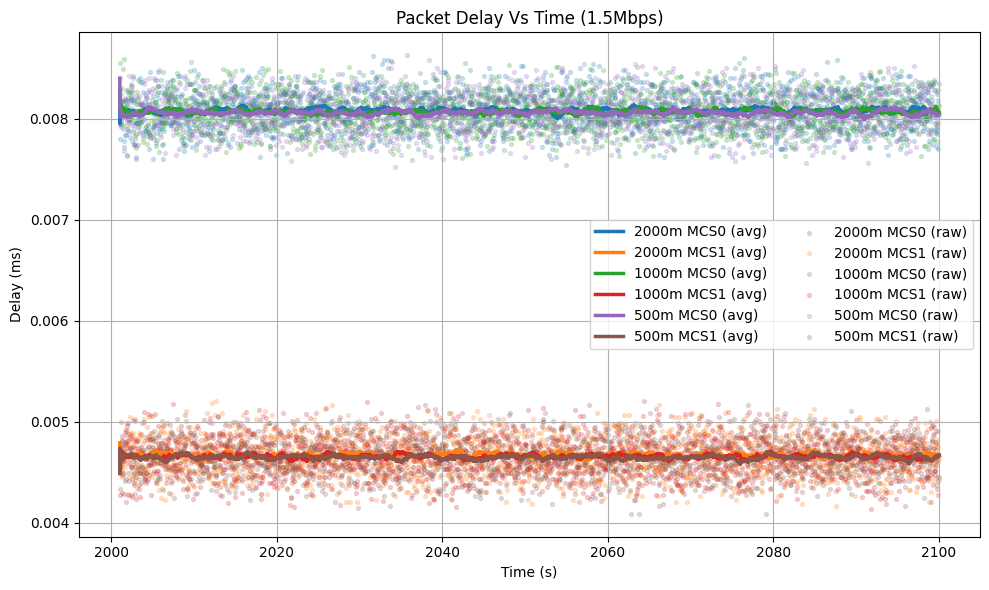

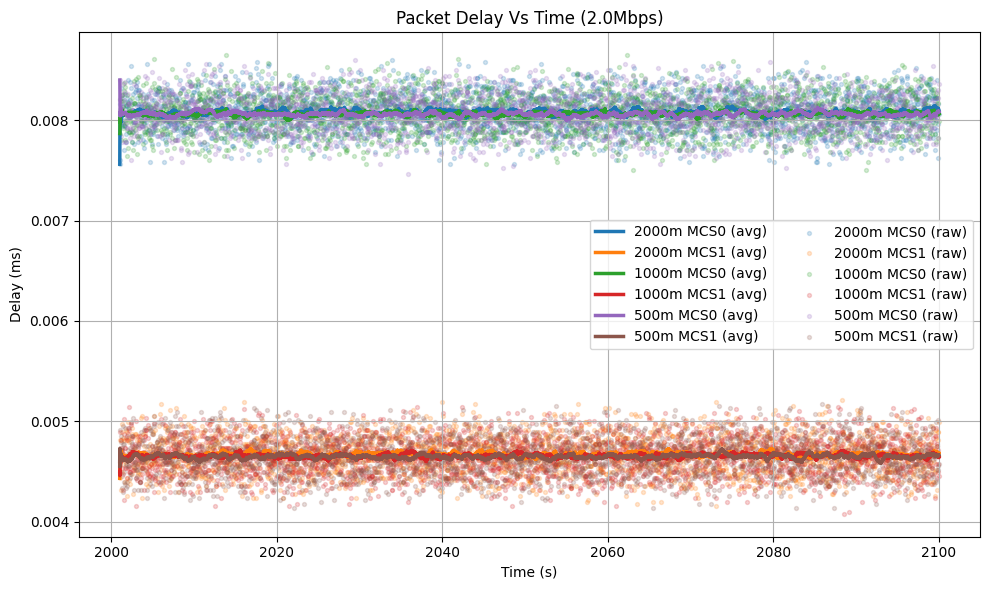

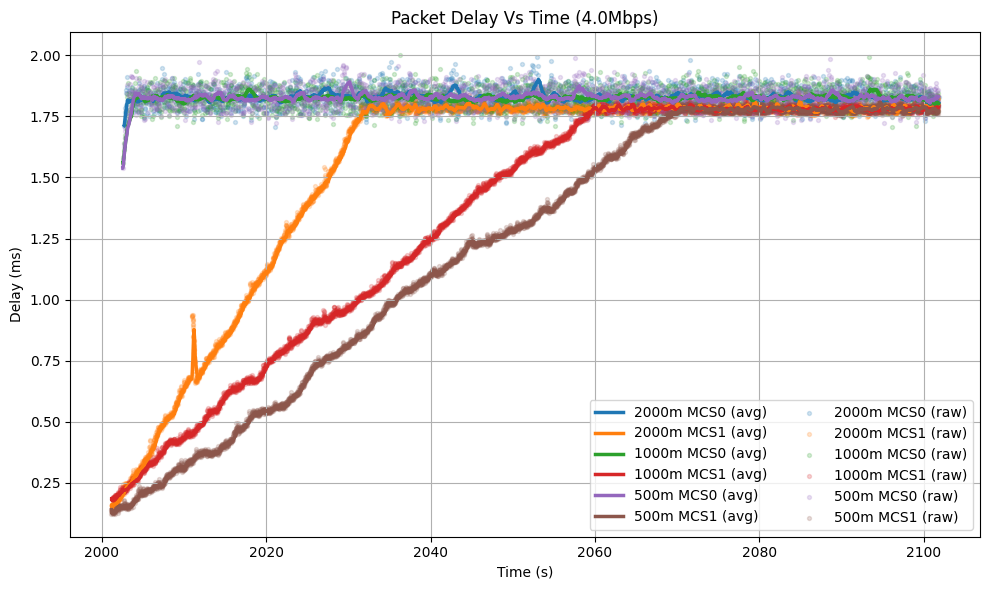

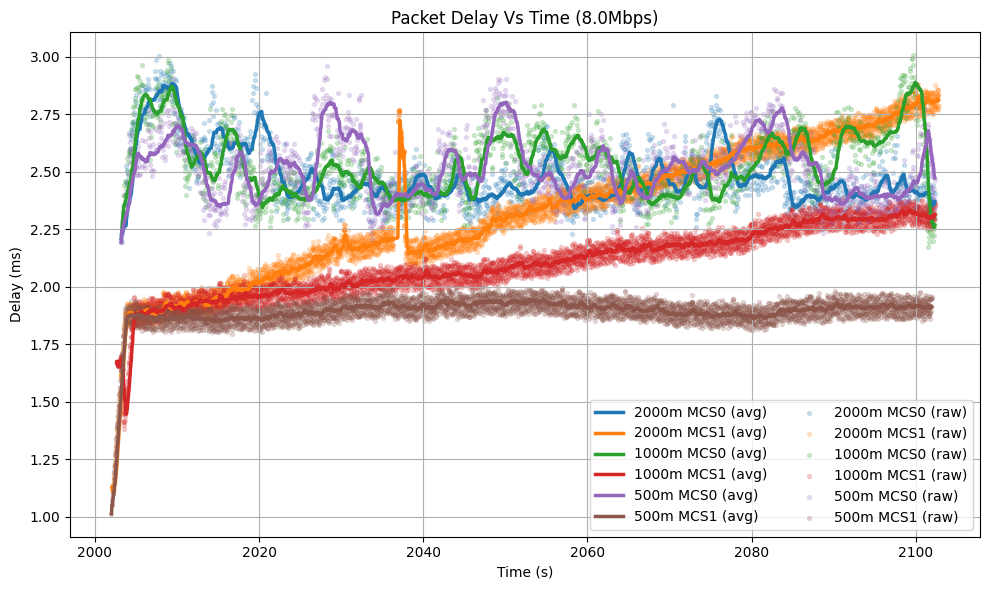

In [42]:
def plot_delay_over_time(records_folder: str, flow_mask: list, ith=1, nth=5, scatter_alpha=0.2, window=100):
    """
    Plot per-packet delay over time for all flows.
    Shows raw delays as scatter + smoothed rolling average as line.
    Automatically adapts to simulation time range.
    """
    data_rate = float(flow_mask[0][-5:-2].replace("-","."))
    delay_plot_path = os.path.join(records_folder, f"delay_over_time_{str(data_rate).replace(".","-")}Mbps.png")
    flows = [os.path.join(records_folder, f) for f in flow_mask]
    csv_files = []
    for flow in flows:
        [csv_files.append(os.path.join(flow,f)) for f in os.listdir(flow) if f.endswith(".csv") and "Flow_Node" in f]
    
    if not csv_files:
        print("No flow CSV files found for delay plotting.")
        return

    plt.figure(figsize=(10,6))

    for file in csv_files:
        file_path = os.path.join(records_folder, file)
        df = pd.read_csv(file_path)

        # Clean packet IDs
        def get_base_packet_id(packet_id):
            return re.match(r"(.+)_\w+$", packet_id).group(1)
        df['Base Packet ID'] = df['Pkt ID'].apply(get_base_packet_id)
        df = df.groupby('Base Packet ID').tail(1).reset_index(drop=True)

        # Keep only valid delays
        df = df[(df['Delay (in s)'] > 0) & (df['Delay (in s)'] != float('inf'))]
        df = df.drop(df[df['Generation Time (in s)'] <= 2000+ith].index)
        if df.empty:
            continue

        # Reception time = generation + delay
        df['Reception Time (s)'] = df['Generation Time (in s)'] + df['Delay (in s)']
        df = df.sort_values('Reception Time (s)')

        flow_id = "".join([file.split("\\")[-2].replace(".csv", "").split("_")[3],
                          'm_MCS',
                          file.split("\\")[-2].replace(".csv", "").split("_")[-1],
                          ]).replace("_", " ")

        # Scatter plot (raw points)
        scatter_sample = df.iloc[::nth, :]

        # Smoothed line (rolling mean)
        df['Delay MA'] = df['Delay (in s)'].rolling(window=window, min_periods=1).mean()
        # df['Delay MA'] = df['Delay (in s)'].rolling(window=window, min_periods=1).apply(lambda x: x[10:].mean())
        
        plt.plot(df['Reception Time (s)'], df['Delay MA'],
                 linewidth=2.5, label=f"{flow_id} (avg)")
        plt.scatter(scatter_sample['Reception Time (s)'],
                    scatter_sample['Delay (in s)'],
                    s=8, alpha=scatter_alpha, label=f"{flow_id} (raw)")

    plt.xlabel("Time (s)")
    plt.ylabel("Delay (ms)")
    plt.title(f"Packet Delay Vs Time ({data_rate}Mbps)")
    plt.grid(True)
    handles, labels = plt.gca().get_legend_handles_labels()
    handles = handles[::2] + handles[1::2]
    labels = labels[::2] + labels[1::2]
    plt.legend(handles, labels, ncols=2)
    plt.tight_layout()
    plt.savefig(delay_plot_path, dpi=300, bbox_inches='tight')
    print(f"Delay-over-time plot saved to: {delay_plot_path}")

    # try:
    #     plt.show()
    # except:
    #     print("Display not available, plot saved to file only.")
    # plt.close()

results_folder = Path('Results_Multi_N100/').resolve()
results = aggregate_data(results_folder)
data_rates = [1.5,2.0,4.0,8.0]
for rate in data_rates:
    flow_mask = [r.short_location for r in results if r.data_rate == rate]
    # print(flow_mask)
    plot_delay_over_time(results_folder, flow_mask)

Plot saved to: C:\Users\Ameliyn\MCA_Routing_BSCAP\Results_Multi_N100\packet_delivery_rate_1-5Mbps.png
Plot saved to: C:\Users\Ameliyn\MCA_Routing_BSCAP\Results_Multi_N100\packet_delivery_rate_2-0Mbps.png
Plot saved to: C:\Users\Ameliyn\MCA_Routing_BSCAP\Results_Multi_N100\packet_delivery_rate_4-0Mbps.png
Plot saved to: C:\Users\Ameliyn\MCA_Routing_BSCAP\Results_Multi_N100\packet_delivery_rate_8-0Mbps.png


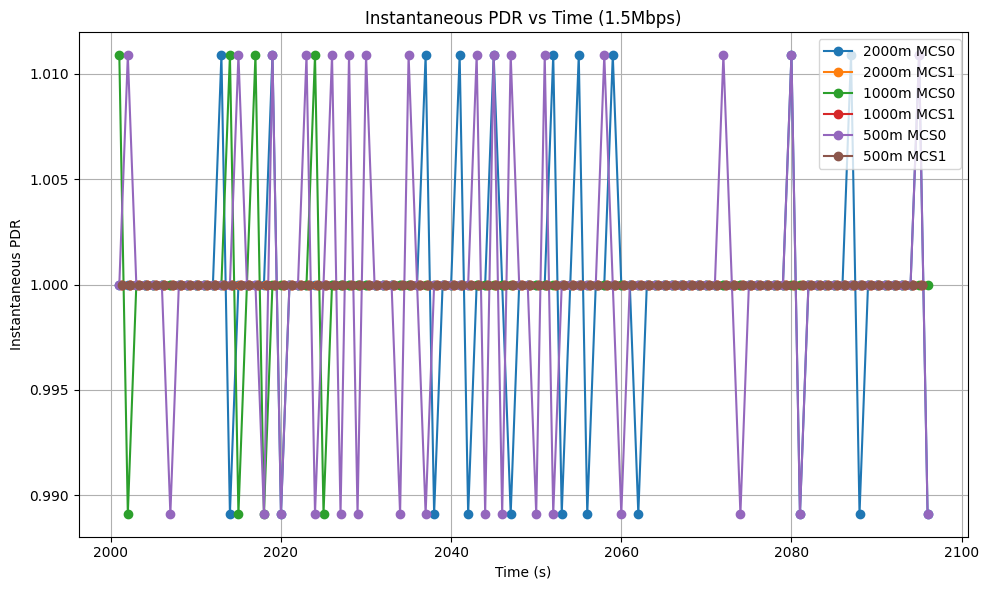

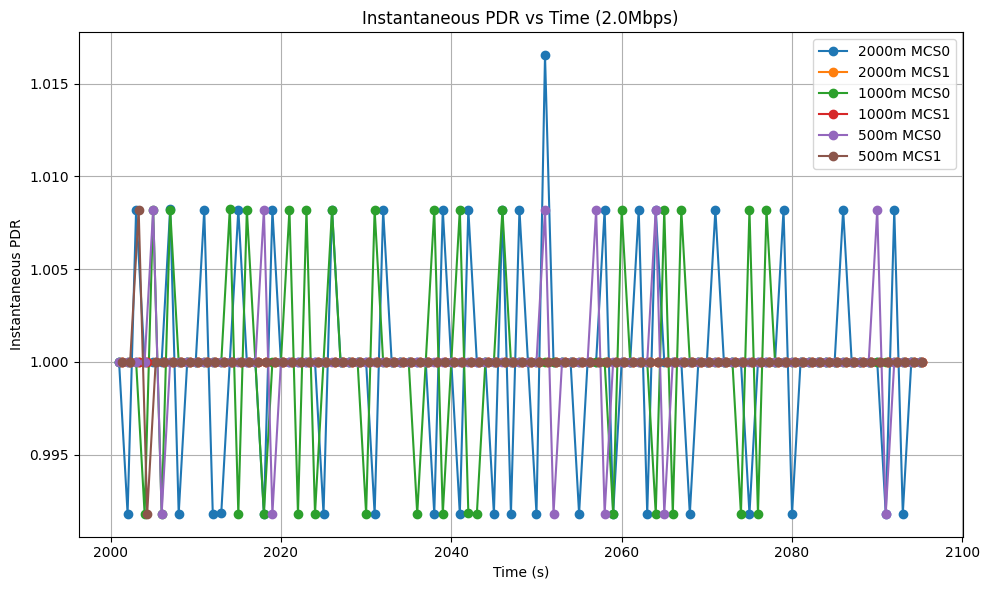

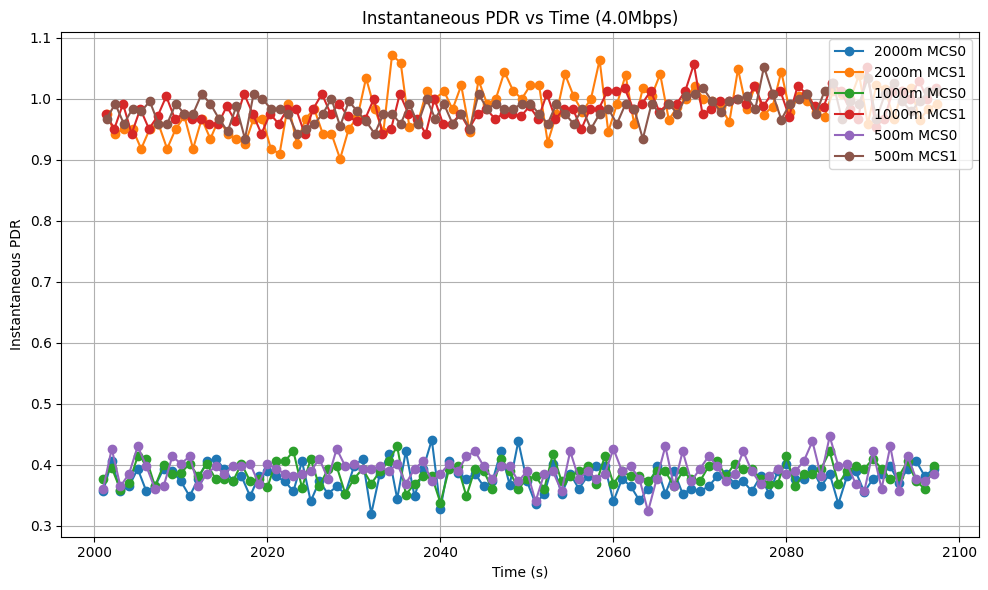

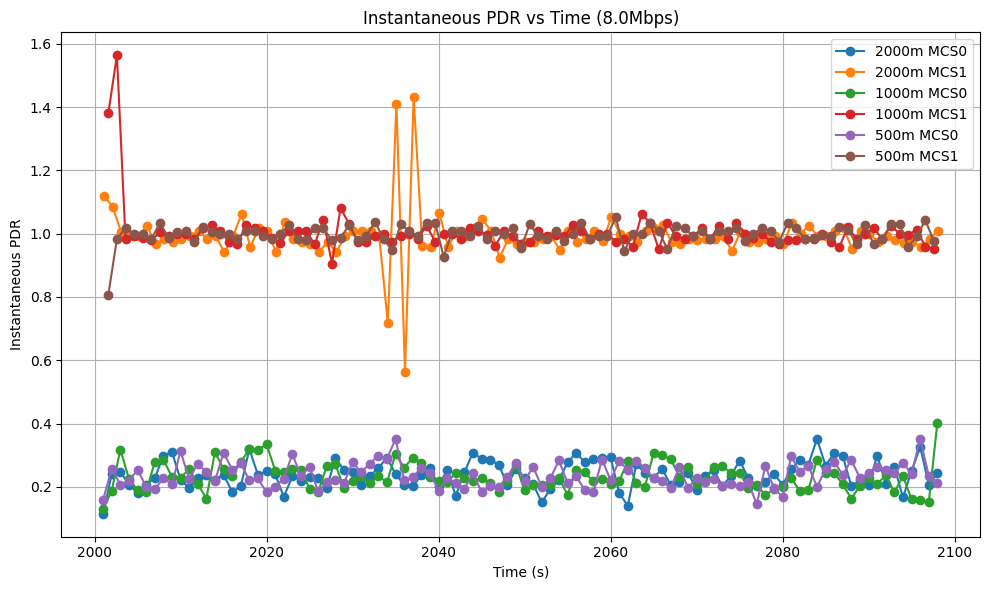

In [43]:
def plot_delivery_rate_over_time(records_folder: str, flow_mask: list, ith=1, nth=5, scatter_alpha=0.2, window=100):
    """
    Plot packet delivery rate over time for all flows.
    Shows raw delays as scatter + smoothed rolling average as line.
    Automatically adapts to simulation time range.
    """
    data_rate = float(flow_mask[0][-5:-2].replace("-","."))
    delay_plot_path = os.path.join(records_folder, f"packet_delivery_rate_{str(data_rate).replace(".","-")}Mbps.png")
    flows = [os.path.join(records_folder, f) for f in flow_mask]
    csv_files = []
    for flow in flows:
        [csv_files.append(os.path.join(flow,f)) for f in os.listdir(flow) if f.endswith(".csv") and "pdr" in f]
    
    if not csv_files:
        print("No flow CSV files found for delivery rate plotting.")
        return

    flows = []
    for file in csv_files:
        file_path = os.path.join(records_folder, file)
        flows.append(pd.read_csv(file_path))
    plt.figure(figsize=(10,6))

    # Find the maximum time across all flows to exclude last 3 seconds
    max_time = 0
    min_time = 99999
    for flow,file in zip(flows,csv_files):
        # flow_df = df[df['Flow_ID'] == flow]
        flow_df = flow      
        
        time_starts = flow_df['Time_Window'].apply(lambda x: float(x.split('-')[0]))
        
        max_time = max(max_time, time_starts.max())
        min_time = min(min_time, time_starts.min())
    
    # Exclude last 3 seconds
    cutoff_time = max_time - 4.0
    start_time = min_time + ith
    
    for flow,file in zip(flows,csv_files):
        # flow_df = df[df['Flow_ID'] == flow]
        flow_df = flow
        # Parse the start of each time window for x-axis
        time_starts = flow_df['Time_Window'].apply(lambda x: float(x.split('-')[0]))
        
        # Filter out data points beyond cutoff_time
        mask = time_starts <= cutoff_time
        temp_filtered_time_starts = time_starts[mask]
        temp_filtered_pdr = flow_df['Instantaneous_PDR'][mask]
        
        mask = temp_filtered_time_starts >= start_time
        filtered_time_starts = temp_filtered_time_starts[mask]
        filtered_pdr = temp_filtered_pdr[mask]
        flow_id = "".join([file.split("\\")[-2].replace(".csv", "").split("_")[3],
                          'm_MCS',
                          file.split("\\")[-2].replace(".csv", "").split("_")[-1],
                          ]).replace("_", " ")
        plt.plot(filtered_time_starts, filtered_pdr, marker='o', label=flow_id)
    
    plt.xlabel('Time (s)')
    plt.ylabel('Instantaneous PDR')
    plt.title(f'Instantaneous PDR vs Time ({data_rate}Mbps)')
    plt.grid(True)
    plt.legend(loc='upper right')
    plt.tight_layout()
    
    # Save the plot to a file
    plt.savefig(delay_plot_path, dpi=300, bbox_inches='tight')
    print(f"Plot saved to: {delay_plot_path}")
        

results_folder = Path('Results_Multi_N100/').resolve()
results = aggregate_data(results_folder)
data_rates = [1.5,2.0,4.0,8.0]

for rate in data_rates:
    flow_mask = [r.short_location for r in results if r.data_rate == rate]
    # print(flow_mask)
    plot_delivery_rate_over_time(results_folder, flow_mask)

Delay-over-time plot saved to: C:\Users\Ameliyn\MCA_Routing_BSCAP\Results_Multi_N100\retransmission_over_time_1-5Mbps.png
Delay-over-time plot saved to: C:\Users\Ameliyn\MCA_Routing_BSCAP\Results_Multi_N100\retransmission_over_time_2-0Mbps.png
Delay-over-time plot saved to: C:\Users\Ameliyn\MCA_Routing_BSCAP\Results_Multi_N100\retransmission_over_time_4-0Mbps.png
Delay-over-time plot saved to: C:\Users\Ameliyn\MCA_Routing_BSCAP\Results_Multi_N100\retransmission_over_time_8-0Mbps.png


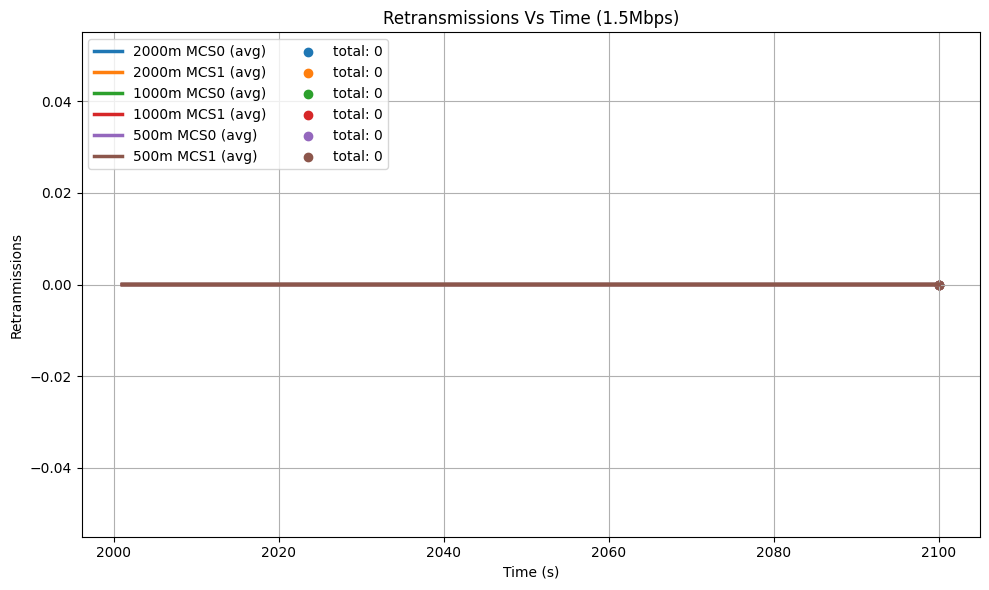

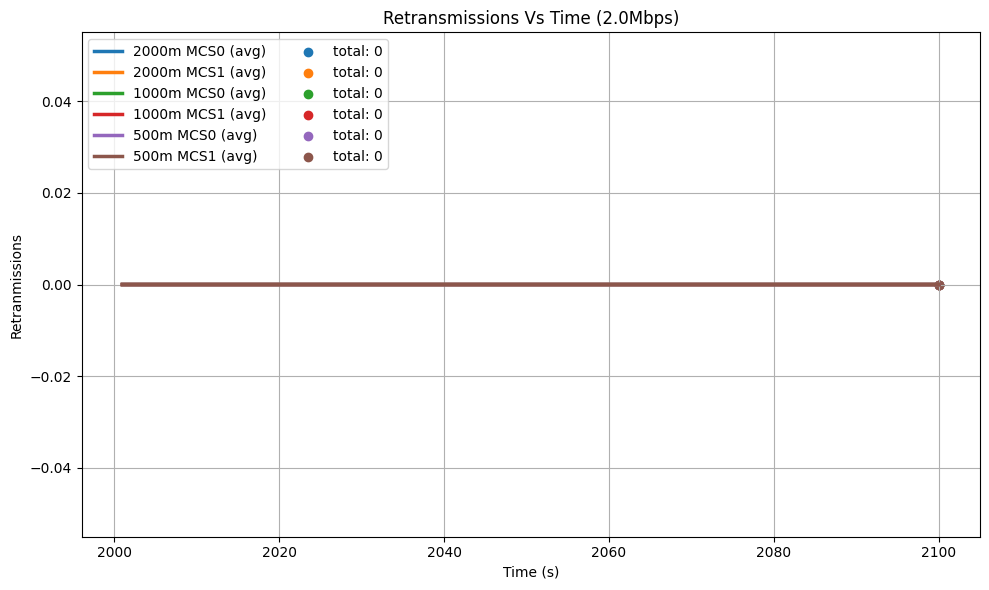

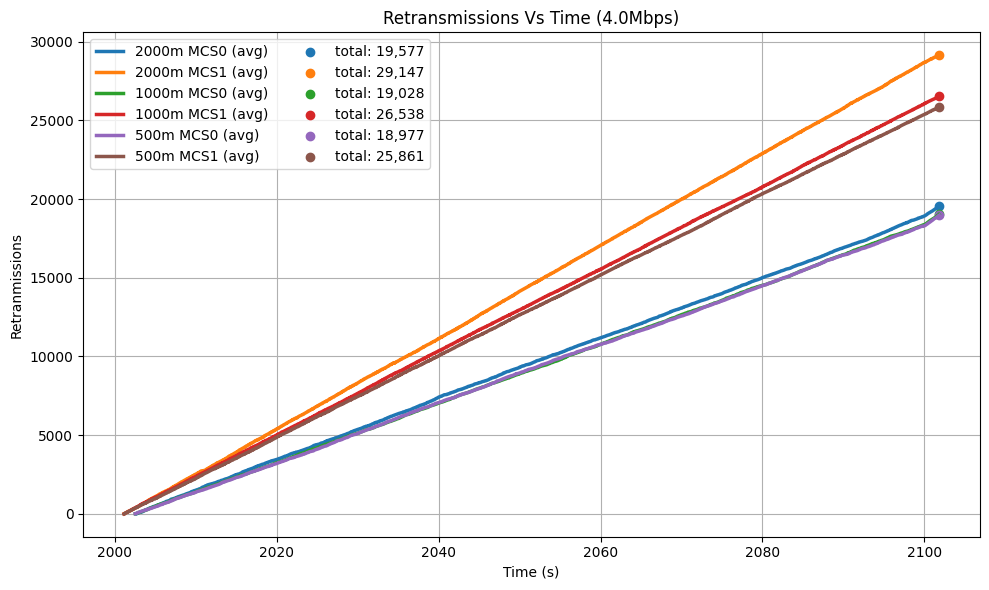

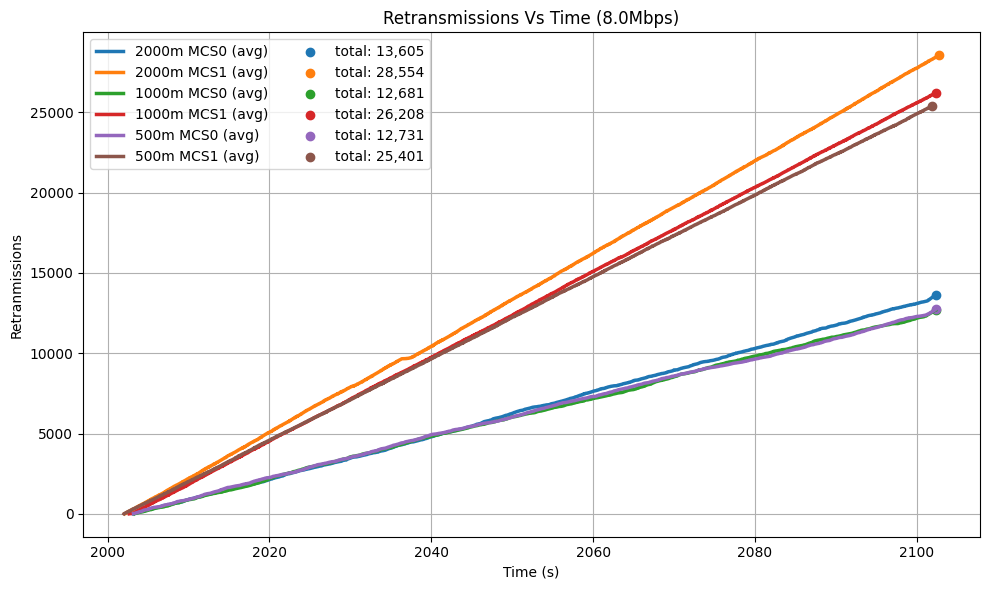

In [44]:
def plot_retransmission_over_time(records_folder: str, flow_mask: list, ith=1, nth=5, scatter_alpha=0.2, window=100):
    """
    Plot per-packet retransmission over time for all flows.
    Shows raw delays as scatter + smoothed rolling average as line.
    Automatically adapts to simulation time range.
    """
    data_rate = float(flow_mask[0][-5:-2].replace("-","."))
    delay_plot_path = os.path.join(records_folder, f"retransmission_over_time_{str(data_rate).replace(".","-")}Mbps.png")
    flows = [os.path.join(records_folder, f) for f in flow_mask]
    csv_files = []
    for flow in flows:
        [csv_files.append(os.path.join(flow,f)) for f in os.listdir(flow) if f.endswith(".csv") and "Flow_Node" in f]
    
    if not csv_files:
        print("No flow CSV files found for delay plotting.")
        return

    plt.figure(figsize=(10,6))

    for file in csv_files:
        file_path = os.path.join(records_folder, file)
        df = pd.read_csv(file_path)

        # Clean packet IDs
        def get_base_packet_id(packet_id):
            return re.match(r"(.+)_\w+$", packet_id).group(1)
        df['Base Packet ID'] = df['Pkt ID'].apply(get_base_packet_id)
        df = df.groupby('Base Packet ID').tail(1).reset_index(drop=True)

        # Keep only valid delays
        df = df[(df['Delay (in s)'] > 0) & (df['Delay (in s)'] != float('inf'))]
        df = df.drop(df[df['Generation Time (in s)'] <= 2000+ith].index)
        if df.empty:
            continue

        # Reception time = generation + delay
        df['Reception Time (s)'] = df['Generation Time (in s)'] + df['Delay (in s)']
        df = df.sort_values('Reception Time (s)')

        flow_id = "".join([file.split("\\")[-2].replace(".csv", "").split("_")[3],
                          'm_MCS',
                          file.split("\\")[-2].replace(".csv", "").split("_")[-1],
                          ]).replace("_", " ")

        # Scatter plot (raw points)
        # scatter_sample = df.iloc[::nth, :]
        # plt.scatter(scatter_sample['Reception Time (s)'],
        #             scatter_sample['Retransmissions'],
        #             s=8, alpha=scatter_alpha, label=f"{flow_id} (raw)")

        # Smoothed line (rolling mean)
        df['Retransmission MA'] = df['Retransmissions'].rolling(window=window, min_periods=1).mean()
        df['Total Retransmission'] = df['Retransmissions'].cumsum()
        # df['Delay MA'] = df['Delay (in s)'].rolling(window=window, min_periods=1).apply(lambda x: x[10:].mean())
        
        plt.plot(df['Reception Time (s)'], df['Total Retransmission'],
                 linewidth=2.5, label=f"{flow_id} (avg)")
        last_x = df['Reception Time (s)'].max()
        last_y = df['Total Retransmission'].max()
        plt.scatter(last_x, last_y, label=f'total: {last_y:,}')
        
    plt.xlabel("Time (s)")
    plt.ylabel("Retranmissions")
    plt.title(f"Retransmissions Vs Time ({data_rate}Mbps)")
    plt.grid(True)
    handles, labels = plt.gca().get_legend_handles_labels()
    handles = handles[::2] + handles[1::2]
    labels = labels[::2] + labels[1::2]
    plt.legend(handles, labels, ncols=2, loc='upper left')
    plt.tight_layout()
    plt.savefig(delay_plot_path, dpi=300, bbox_inches='tight')
    print(f"Delay-over-time plot saved to: {delay_plot_path}")

    # try:
    #     plt.show()
    # except:
    #     print("Display not available, plot saved to file only.")
    # plt.close()

results_folder = Path('Results_Multi_N100/').resolve()
results = aggregate_data(results_folder)
data_rates = [1.5,2.0,4.0,8.0]
for rate in data_rates:
    flow_mask = [r.short_location for r in results if r.data_rate == rate]
    # print(flow_mask)
    plot_retransmission_over_time(results_folder, flow_mask)

Energy-over-time plot saved to: C:\Users\Ameliyn\MCA_Routing_BSCAP\Results_Multi_N100\tx_energy_over_time_1-5Mbps.png
Energy-over-time plot saved to: C:\Users\Ameliyn\MCA_Routing_BSCAP\Results_Multi_N100\tx_energy_over_time_2-0Mbps.png
Energy-over-time plot saved to: C:\Users\Ameliyn\MCA_Routing_BSCAP\Results_Multi_N100\tx_energy_over_time_4-0Mbps.png
Energy-over-time plot saved to: C:\Users\Ameliyn\MCA_Routing_BSCAP\Results_Multi_N100\tx_energy_over_time_8-0Mbps.png


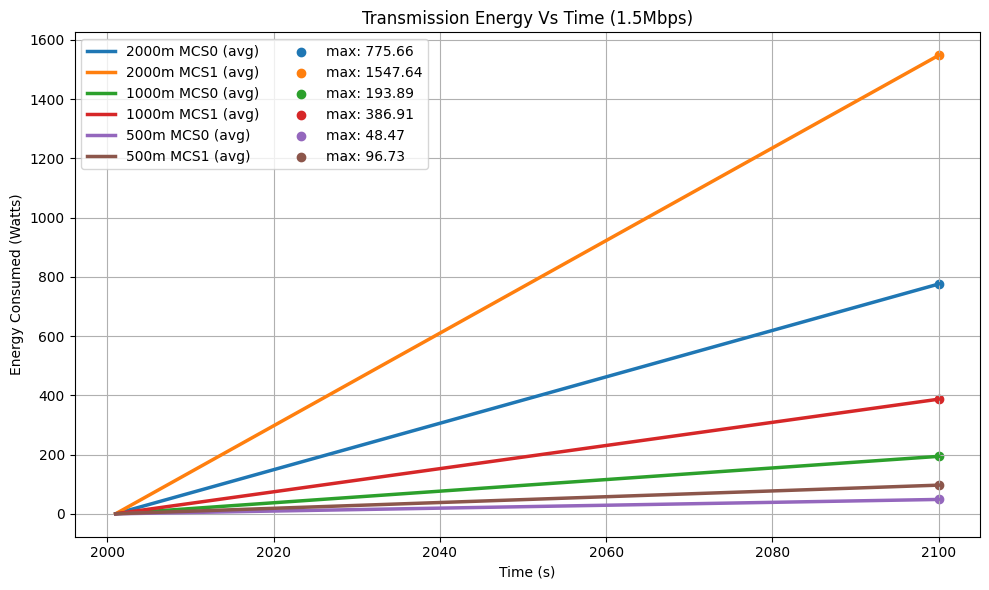

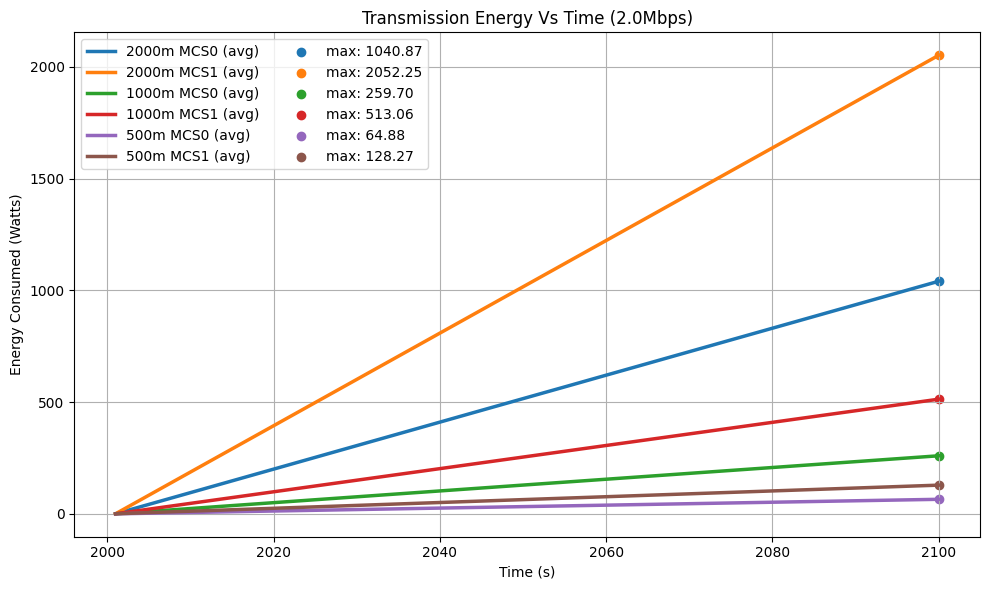

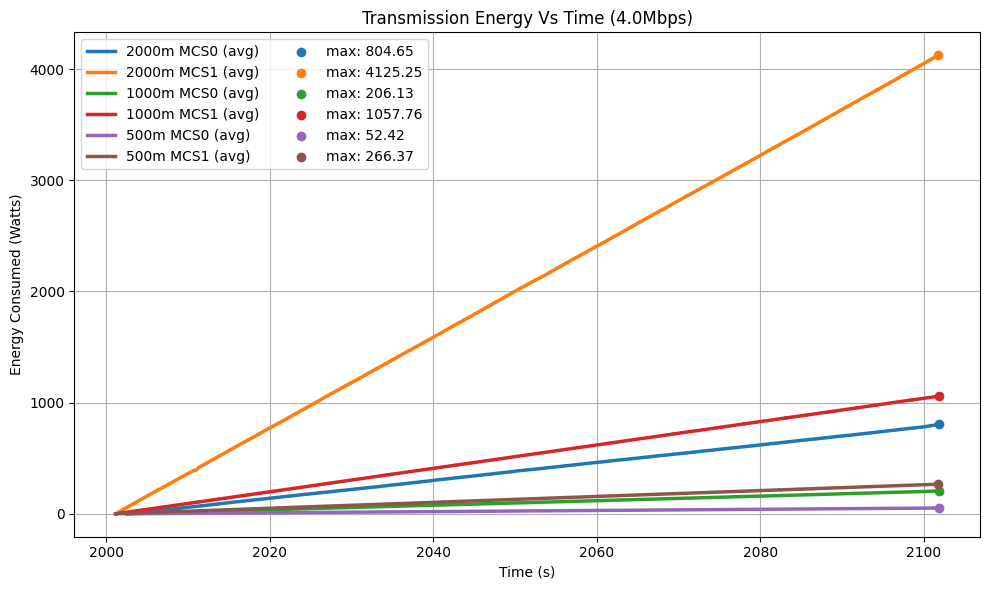

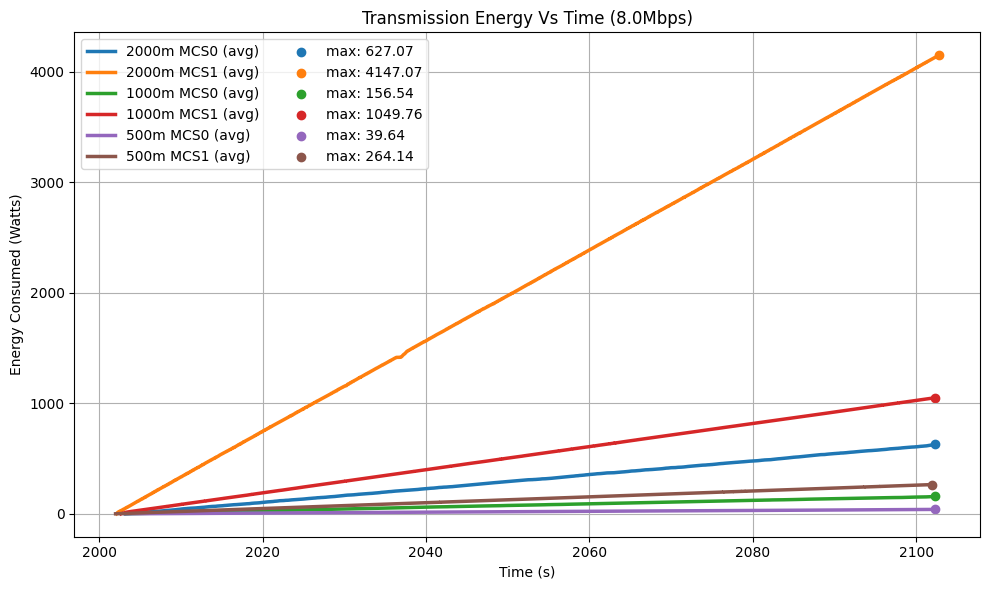

In [45]:
import numpy as np
def plot_energy_over_time(records_folder: str, flow_mask: list, ith=1, nth=5, scatter_alpha=0.2, window=100):
    """
    Plot energy over time for all flows.
    Automatically adapts to simulation time range.
    """
    data_rate = float(flow_mask[0][-5:-2].replace("-","."))
    energy_plot_path = os.path.join(records_folder, f"tx_energy_over_time_{str(data_rate).replace(".","-")}Mbps.png")
    flows = [os.path.join(records_folder, f) for f in flow_mask]
    csv_files = []
    for flow in flows:
        [csv_files.append(os.path.join(flow,f)) for f in os.listdir(flow) if f.endswith(".csv") and "Flow_Node" in f]
    
    if not csv_files:
        print("No flow CSV files found for delay plotting.")
        return

    plt.figure(figsize=(10,6))

    for file in csv_files:
        file_path = os.path.join(records_folder, file)
        df = pd.read_csv(file_path)

        # Clean packet IDs
        def get_base_packet_id(packet_id):
            return re.match(r"(.+)_\w+$", packet_id).group(1)
        df['Base Packet ID'] = df['Pkt ID'].apply(get_base_packet_id)
        df = df.groupby('Base Packet ID').tail(1).reset_index(drop=True)

        # Keep only valid delays
        df = df[(df['Delay (in s)'] > 0) & (df['Delay (in s)'] != float('inf'))]
        df = df.drop(df[df['Generation Time (in s)'] <= 2000+ith].index)
        if df.empty:
            continue

        # Reception time = generation + delay
        df['Reception Time (s)'] = df['Generation Time (in s)'] + df['Delay (in s)']
        df = df.sort_values('Reception Time (s)')

        flow_id = "".join([file.split("\\")[-2].replace(".csv", "").split("_")[3],
                          'm_MCS',
                          file.split("\\")[-2].replace(".csv", "").split("_")[-1],
                          ]).replace("_", " ")
        
        df['Total Energy'] = df['Tx Power (in watt)'].apply(lambda x: sum(np.array(x.split(",")).astype(np.float64)))
        df['Total Energy Sum'] = df['Total Energy'].cumsum()
        
        plt.plot(df['Reception Time (s)'], df['Total Energy Sum'],
                 linewidth=2.5, label=f"{flow_id} (avg)")

        last_x = df['Reception Time (s)'].max()
        last_y = df['Total Energy Sum'].max()
        plt.scatter(last_x, last_y, label=f'max: {last_y:.2f}')
    plt.xlabel("Time (s)")
    plt.ylabel("Energy Consumed (Watts)")
    plt.title(f"Transmission Energy Vs Time ({data_rate}Mbps)")
    plt.grid(True)
    
    handles, labels = plt.gca().get_legend_handles_labels()
    handles = handles[::2] + handles[1::2]
    labels = labels[::2] + labels[1::2]
    plt.legend(handles, labels, ncols=2)
    plt.tight_layout()
    plt.savefig(energy_plot_path, dpi=300, bbox_inches='tight')
    print(f"Energy-over-time plot saved to: {energy_plot_path}")

    # try:
    #     plt.show()
    # except:
    #     print("Display not available, plot saved to file only.")
    # plt.close()

results_folder = Path('Results_Multi_N100/').resolve()
results = aggregate_data(results_folder)
data_rates = [1.5,2.0,4.0,8.0]
for rate in data_rates:
    flow_mask = [r.short_location for r in results if r.data_rate == rate]
    # print(flow_mask)
    plot_energy_over_time(results_folder, flow_mask)